# Diffusion Model Validation

## Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from implied_volatility_diffusion import (
    DiffusionModel,
    ReverseDiffusion,
    SurfaceNormalizer,
    UnifiedGrid,
    UNet,
    VPNoiseScheduler,
    check_iv_surface_arbitrage,
    repair_calendar_monotone,
)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110, "axes.grid": False})


def _select_device():
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


DEVICE = _select_device()
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CFG_DIR = REPO_ROOT / "config"
DATASET_ROOT = REPO_ROOT / "data" / "processed" / "forecasting_dataset"
CHECKPOINT_DIR = REPO_ROOT / "data" / "processed" / "checkpoints"
CHECKPOINT_PATH = CHECKPOINT_DIR / "diffusion_unet.pt"
CONFIG_PATH = CHECKPOINT_DIR / "training_config.json"

GRID = UnifiedGrid.load(CFG_DIR / "unified_iv_grid.yaml")

if not (DATASET_ROOT / "manifest.json").exists():
    raise FileNotFoundError(
        f"missing {DATASET_ROOT / 'manifest.json'}; run notebooks/unified_surface_pipeline.ipynb first"
    )
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"missing {CHECKPOINT_PATH}; run notebooks/diffusion_model_training.ipynb first")

print(f"compute device: {DEVICE}")
print(f"unified grid: {GRID.shape}")

compute device: mps
unified grid: (41, 40)


##  Validation Inputs

In [2]:
PATH_TYPES = ("historical", "sabr", "heston")
TENOR_SLICES_PER_SURFACE = 3
DDIM_STEPS = 200
MAX_GENERATION_TRIES = 16
ARB_DIAG_TOL = 1e-6
ARB_ACCEPT_TOL = 1e-4
GENERATED_ARB_TOL = ARB_ACCEPT_TOL
APPLY_CALENDAR_REPAIR = True
IV_FLOOR_SAMPLE = 1e-4
SAMPLER_CLIP_Z = (-4.0, 4.0)

SOURCE_LABELS = {0: "historical", 1: "heston", 2: "sabr"}
PATH_TYPE_TO_SRC_ID = {"historical": 0, "heston": 1, "sabr": 2}
unknown_paths = [p for p in PATH_TYPES if p not in PATH_TYPE_TO_SRC_ID]
if unknown_paths:
    raise ValueError(f"Unknown path types in PATH_TYPES: {unknown_paths}")

run_config = json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}
VALIDATION_SEED = int(run_config.get("seed", 42))
GENERATION_SEEDS = [VALIDATION_SEED + 9000 + i for i in range(len(PATH_TYPES))]

tenor_idx = np.linspace(0, GRID.shape[1] - 1, TENOR_SLICES_PER_SURFACE).round().astype(int)
tenor_idx = np.unique(tenor_idx)
if tenor_idx.size != TENOR_SLICES_PER_SURFACE:
    raise RuntimeError(f"Expected exactly {TENOR_SLICES_PER_SURFACE} unique tenor slices, got {tenor_idx.size}.")

validation_inputs_df = pd.DataFrame(
    [
        {"input": "checkpoint", "value": str(CHECKPOINT_PATH.relative_to(REPO_ROOT))},
        {"input": "training config", "value": str(CONFIG_PATH.relative_to(REPO_ROOT))},
        {"input": "dataset", "value": str(DATASET_ROOT.relative_to(REPO_ROOT))},
        {"input": "validation instances", "value": list(PATH_TYPES)},
        {"input": "tenors shown per surface", "value": TENOR_SLICES_PER_SURFACE},
        {"input": "selected tenor years", "value": np.round(GRID.tau[tenor_idx], 4).tolist()},
        {"input": "DDIM steps", "value": DDIM_STEPS},
        {"input": "base generation seeds", "value": GENERATION_SEEDS},
        {"input": "max generation tries per instance", "value": MAX_GENERATION_TRIES},
        {"input": "strict diagnostic tol", "value": ARB_DIAG_TOL},
        {"input": "soft acceptance tol", "value": ARB_ACCEPT_TOL},
        {"input": "required forecast arbitrage tol", "value": GENERATED_ARB_TOL},
        {"input": "calendar repair", "value": APPLY_CALENDAR_REPAIR},
    ]
)
display(validation_inputs_df)

,input,value
0,checkpoint,data/processed/checkpoints/diffusion_unet.pt
1,training config,data/processed/checkpoints/training_config.json
2,dataset,data/processed/forecasting_dataset
3,validation instances,"[historical, sabr, heston]"
4,tenors shown per surface,3
5,selected tenor years,"[0.05, 1.05, 2.0]"
6,DDIM steps,200
7,base generation seeds,"[9042, 9043, 9044]"
8,max generation tries per instance,16
9,strict diagnostic tol,0.000001


## Load validation pairs and checkpoint

In [3]:
manifest = json.loads((DATASET_ROOT / "manifest.json").read_text())
normalizer = SurfaceNormalizer.load(DATASET_ROOT / "normalizer.npz")
assert tuple(normalizer.grid_shape) == tuple(GRID.shape), (
    f"normalizer grid {normalizer.grid_shape} != unified grid {GRID.shape}"
)

VAL_DIR = DATASET_ROOT / "validation"
val_pair_curr = np.load(VAL_DIR / "pair_curr.npy").astype(np.float32)
val_pair_next = np.load(VAL_DIR / "pair_next.npy").astype(np.float32)
val_sources = np.load(VAL_DIR / "pair_sources.npy")

pair_curr_by_src = {}
pair_next_by_src = {}
for _src_id in [0, 1, 2]:
    _mask = val_sources == _src_id
    pair_curr_by_src[_src_id] = val_pair_curr[_mask]
    pair_next_by_src[_src_id] = val_pair_next[_mask]

val_hist_curr_dates = pd.DatetimeIndex(np.load(VAL_DIR / "historical_curr_dates.npy"))
val_hist_next_dates = pd.DatetimeIndex(np.load(VAL_DIR / "historical_next_dates.npy"))
val_heston_paths = np.load(VAL_DIR / "heston_path.npy")
val_heston_steps = np.load(VAL_DIR / "heston_step.npy")
val_sabr_paths = np.load(VAL_DIR / "sabr_path.npy")
val_sabr_steps = np.load(VAL_DIR / "sabr_step.npy")

n_pairs_by_src = {k: int(v.shape[0]) for k, v in pair_curr_by_src.items()}
print(
    f"validation pairs by source -- historical={n_pairs_by_src[0]}  "
    f"heston={n_pairs_by_src[1]}  sabr={n_pairs_by_src[2]}"
    f"  (total={sum(n_pairs_by_src.values())})"
)

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
SCHEDULER_TIMESTEPS = int(checkpoint.get("scheduler_timesteps", run_config.get("scheduler_timesteps", 400)))
UNET_KWARGS = dict(checkpoint.get("unet_kwargs", run_config.get("unet_kwargs", {})))
SPOT_REF = float(checkpoint.get("spot_ref", run_config.get("spot_ref", 100.0)))
RATE_REF = float(checkpoint.get("rate_ref", run_config.get("rate_ref", 0.03)))

cond_channels = int(UNET_KWARGS.get("cond_channels", 0))
if cond_channels < 1:
    raise RuntimeError(
        "Loaded checkpoint is unconditional (cond_channels=0). Re-run "
        "notebooks/diffusion_model_training.ipynb to produce a conditional checkpoint."
    )

scheduler = VPNoiseScheduler(timesteps=SCHEDULER_TIMESTEPS, beta_schedule="cosine")
model = DiffusionModel.from_surface_normalizer(UNet(**UNET_KWARGS), scheduler, normalizer).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
sampler = ReverseDiffusion(model)

moneyness = np.exp(GRID.log_moneyness)
SAMPLER_USE_GENERATOR = DEVICE.type == "cpu"

summary_df = pd.DataFrame(
    [
        {"artifact": "manifest sample date", "value": manifest.get("sample_date")},
        {"artifact": "checkpoint timesteps", "value": SCHEDULER_TIMESTEPS},
        {"artifact": "spot / rate", "value": f"{SPOT_REF:.2f} / {RATE_REF:.4f}"},
        {"artifact": "U-Net kwargs", "value": UNET_KWARGS},
        {"artifact": "conditional", "value": True},
    ]
)
display(summary_df)

validation pairs by source -- historical=249  heston=198  sabr=595  (total=1042)


,artifact,value
0,manifest sample date,2021-06-17
1,checkpoint timesteps,400
2,spot / rate,100.00 / 0.0300
3,U-Net kwargs,"{'in_channels': 1, 'out_channels': 1, 'cond_ch..."
4,conditional,True


## Conditional forecast

In [4]:
def _surface_label(src_id, pair_idx):
    if src_id == 0:
        if pair_idx < len(val_hist_curr_dates):
            return (
                f"date={val_hist_curr_dates[pair_idx].date()}",
                f"date={val_hist_next_dates[pair_idx].date()}",
            )
        return f"idx={pair_idx}", f"idx={pair_idx}"
    if src_id == 1:
        path = int(val_heston_paths[pair_idx])
        step = int(val_heston_steps[pair_idx])
        return f"path={path}, step={step}", f"path={path}, step={step + 1}"
    path = int(val_sabr_paths[pair_idx])
    step = int(val_sabr_steps[pair_idx])
    return f"path={path}, step={step}", f"path={path}, step={step + 1}"


def _maybe_guard(iv):
    if not APPLY_CALENDAR_REPAIR:
        return np.asarray(iv, dtype=np.float64)
    iv_floor = np.clip(iv, IV_FLOOR_SAMPLE, None)
    return repair_calendar_monotone(iv_floor, GRID.tau)


def _arb_score(report):
    return float(
        max(
            -min(0.0, report.worst_butterfly),
            -min(0.0, report.worst_calendar),
            -min(0.0, report.worst_bound),
        )
    )


def _pick_validation_pair(src_id):
    rng = np.random.default_rng(VALIDATION_SEED + 5000 + src_id)
    n_pairs = pair_curr_by_src[src_id].shape[0]
    if n_pairs == 0:
        raise RuntimeError(f"No validation pairs available for source {src_id}")
    pick = int(rng.choice(n_pairs))
    s_curr = pair_curr_by_src[src_id][pick].astype(np.float64)
    s_next = pair_next_by_src[src_id][pick].astype(np.float64)
    input_label, gt_label = _surface_label(src_id, pick)
    return pick, s_curr, s_next, input_label, gt_label


@torch.no_grad()
def _conditional_forecast(s_curr, base_seed):
    cond_iv = torch.as_tensor(s_curr, dtype=torch.float32, device=DEVICE)[None, None]
    cond_z = model.normalize(cond_iv)

    best_forecast = None
    best_meta = None
    best_score = float("inf")

    for attempt in range(1, MAX_GENERATION_TRIES + 1):
        seed = int(base_seed + attempt - 1)
        if SAMPLER_USE_GENERATOR:
            sample_generator = torch.Generator().manual_seed(seed)
        else:
            sample_generator = None
            torch.manual_seed(seed)

        forecast_iv = (
            sampler.ddim_sample(
                batch_size=1,
                num_steps=DDIM_STEPS,
                eta=0.0,
                cond=cond_z,
                generator=sample_generator,
                clip_z=SAMPLER_CLIP_Z,
            )
            .detach()
            .cpu()
            .numpy()[0, 0]
            .astype(np.float64)
        )
        guarded = _maybe_guard(forecast_iv)
        report = check_iv_surface_arbitrage(
            guarded,
            moneyness,
            GRID.tau,
            spot=SPOT_REF,
            rate=RATE_REF,
            tol=GENERATED_ARB_TOL,
        )
        score = _arb_score(report)
        if score < best_score:
            best_score = score
            best_forecast = guarded
            best_meta = {
                "base_seed": int(base_seed),
                "accepted_seed": seed,
                "attempts": attempt,
                "forecast_arb_free": bool(report.arbitrage_free),
                "forecast_arb_tol": GENERATED_ARB_TOL,
                "worst_butterfly": float(report.worst_butterfly),
                "worst_calendar": float(report.worst_calendar),
                "worst_bound": float(report.worst_bound),
            }
        if report.arbitrage_free:
            break

    assert best_forecast is not None and best_meta is not None
    return best_forecast, best_meta


instances = []
for instance_idx, path_type in enumerate(PATH_TYPES):
    src_id = PATH_TYPE_TO_SRC_ID[path_type]
    pick, s_curr, s_next, input_label, gt_label = _pick_validation_pair(src_id)
    base_seed = int(GENERATION_SEEDS[instance_idx])
    forecast, meta = _conditional_forecast(s_curr, base_seed)
    instances.append(
        {
            "path_type": path_type,
            "pair_idx": pick,
            "input_label": input_label,
            "gt_label": gt_label,
            "input": s_curr,
            "ground_truth": s_next,
            "forecast": forecast,
            "meta": meta,
        }
    )

surface_inputs_df = pd.DataFrame(
    [
        {
            "instance": i + 1,
            "path_type": inst["path_type"],
            "pair_idx": int(inst["pair_idx"]),
            "input_label": inst["input_label"],
            "gt_label": inst["gt_label"],
            "base_seed": int(inst["meta"]["base_seed"]),
            "accepted_seed": int(inst["meta"]["accepted_seed"]),
            "generation_attempts": int(inst["meta"]["attempts"]),
            "forecast_arb_free": bool(inst["meta"]["forecast_arb_free"]),
            "worst_butterfly": float(inst["meta"]["worst_butterfly"]),
            "worst_calendar": float(inst["meta"]["worst_calendar"]),
            "worst_bound": float(inst["meta"]["worst_bound"]),
            "tenor_years_shown": np.round(GRID.tau[tenor_idx], 4).tolist(),
        }
        for i, inst in enumerate(instances)
    ]
)
display(surface_inputs_df)

,instance,path_type,pair_idx,input_label,gt_label,base_seed,accepted_seed,generation_attempts,forecast_arb_free,worst_butterfly,worst_calendar,worst_bound,tenor_years_shown
0,1,historical,76,date=2023-04-24,date=2023-04-25,9042,9052,11,False,-0.407634,-5.551115e-17,4.971761e-07,"[0.05, 1.05, 2.0]"
1,2,sabr,73,"path=1, step=73","path=1, step=74",9043,9049,7,False,-0.000447,-3.469447e-18,-2.131628e-14,"[0.05, 1.05, 2.0]"
2,3,heston,114,"path=12, step=15","path=12, step=16",9044,9046,3,False,-0.537684,-5.551115e-17,3.017641e-12,"[0.05, 1.05, 2.0]"


## No-arbitrage diagnostics

In [5]:
def _report_row(kind, instance, path_type, label, iv):
    strict = check_iv_surface_arbitrage(iv, moneyness, GRID.tau, spot=SPOT_REF, rate=RATE_REF, tol=ARB_DIAG_TOL)
    soft = check_iv_surface_arbitrage(iv, moneyness, GRID.tau, spot=SPOT_REF, rate=RATE_REF, tol=ARB_ACCEPT_TOL)
    return {
        "instance": instance,
        "path_type": path_type,
        "kind": kind,
        "label": label,
        "strict_arb_free": bool(strict.arbitrage_free),
        "soft_arb_free": bool(soft.arbitrage_free),
        "worst_butterfly": float(strict.worst_butterfly),
        "worst_calendar": float(strict.worst_calendar),
        "worst_bound": float(strict.worst_bound),
        "n_butterfly": int(strict.n_butterfly_violations),
        "n_calendar": int(strict.n_calendar_violations),
        "n_bound": int(strict.n_bound_violations),
    }


validation_rows = []
for i, inst in enumerate(instances, start=1):
    path_type = str(inst["path_type"])
    validation_rows.append(
        _report_row(f"input ($S_t$): {inst['input_label']}", i, path_type, inst["input_label"], inst["input"])
    )
    validation_rows.append(
        _report_row(
            f"ground truth ($S_{{t+1}}$): {inst['gt_label']}", i, path_type, inst["gt_label"], inst["ground_truth"]
        )
    )
    validation_rows.append(
        _report_row(
            "forecast",
            i,
            path_type,
            f"forecast (seed={inst['meta']['accepted_seed']})",
            inst["forecast"],
        )
    )

surface_validation_df = pd.DataFrame(validation_rows)
display(surface_validation_df)

forecast_error_rows = []
for i, inst in enumerate(instances, start=1):
    diff = inst["forecast"] - inst["ground_truth"]
    diff_5 = diff[:, tenor_idx]
    forecast_error_rows.append(
        {
            "instance": i,
            "path_type": inst["path_type"],
            "input_label": inst["input_label"],
            "gt_label": inst["gt_label"],
            "forecast_seed": int(inst["meta"]["accepted_seed"]),
            "mean_error": float(np.nanmean(diff)),
            "mae": float(np.nanmean(np.abs(diff))),
            "rmse": float(np.sqrt(np.nanmean(diff * diff))),
            "max_abs_error": float(np.nanmax(np.abs(diff))),
            "rmse_on_5_plotted_tenors": float(np.sqrt(np.nanmean(diff_5 * diff_5))),
        }
    )

forecast_error_df = pd.DataFrame(forecast_error_rows)
display(forecast_error_df)

,instance,path_type,kind,label,strict_arb_free,soft_arb_free,worst_butterfly,worst_calendar,worst_bound,n_butterfly,n_calendar,n_bound
0,1,historical,input ($S_t$): date=2023-04-24,date=2023-04-24,False,False,1.971926e-09,-1.774260e-03,1.095854e-07,0,65,0
1,1,historical,ground truth ($S_{t+1}$): date=2023-04-25,date=2023-04-25,False,False,2.146627e-09,-2.525801e-03,1.052914e-07,0,71,0
2,1,historical,forecast,forecast (seed=9052),False,False,-4.076342e-01,-5.551115e-17,4.971761e-07,490,0,0
3,2,sabr,"input ($S_t$): path=1, step=73","path=1, step=73",True,True,-3.780959e-15,2.003181e-05,-2.131628e-14,0,0,0
4,2,sabr,"ground truth ($S_{t+1}$): path=1, step=74","path=1, step=74",True,True,-3.780959e-15,2.060204e-05,-2.131628e-14,0,0,0
5,2,sabr,forecast,forecast (seed=9049),False,False,-4.473499e-04,-3.469447e-18,-2.131628e-14,56,0,0
6,3,heston,"input ($S_t$): path=12, step=15","path=12, step=15",True,True,6.884429e-13,2.542297e-03,4.263256e-14,0,0,0
7,3,heston,"ground truth ($S_{t+1}$): path=12, step=16","path=12, step=16",True,True,7.442110e-13,2.559975e-03,4.973799e-14,0,0,0
8,3,heston,forecast,forecast (seed=9046),False,False,-5.376845e-01,-5.551115e-17,3.017641e-12,576,0,0


,instance,path_type,input_label,gt_label,forecast_seed,mean_error,mae,rmse,max_abs_error,rmse_on_5_plotted_tenors
0,1,historical,date=2023-04-24,date=2023-04-25,9052,0.018455,0.018459,0.020841,0.063486,0.021038
1,2,sabr,"path=1, step=73","path=1, step=74",9049,0.000849,0.000923,0.001264,0.007878,0.001413
2,3,heston,"path=12, step=15","path=12, step=16",9046,0.019974,0.019974,0.021029,0.057057,0.020908


## Model forecast

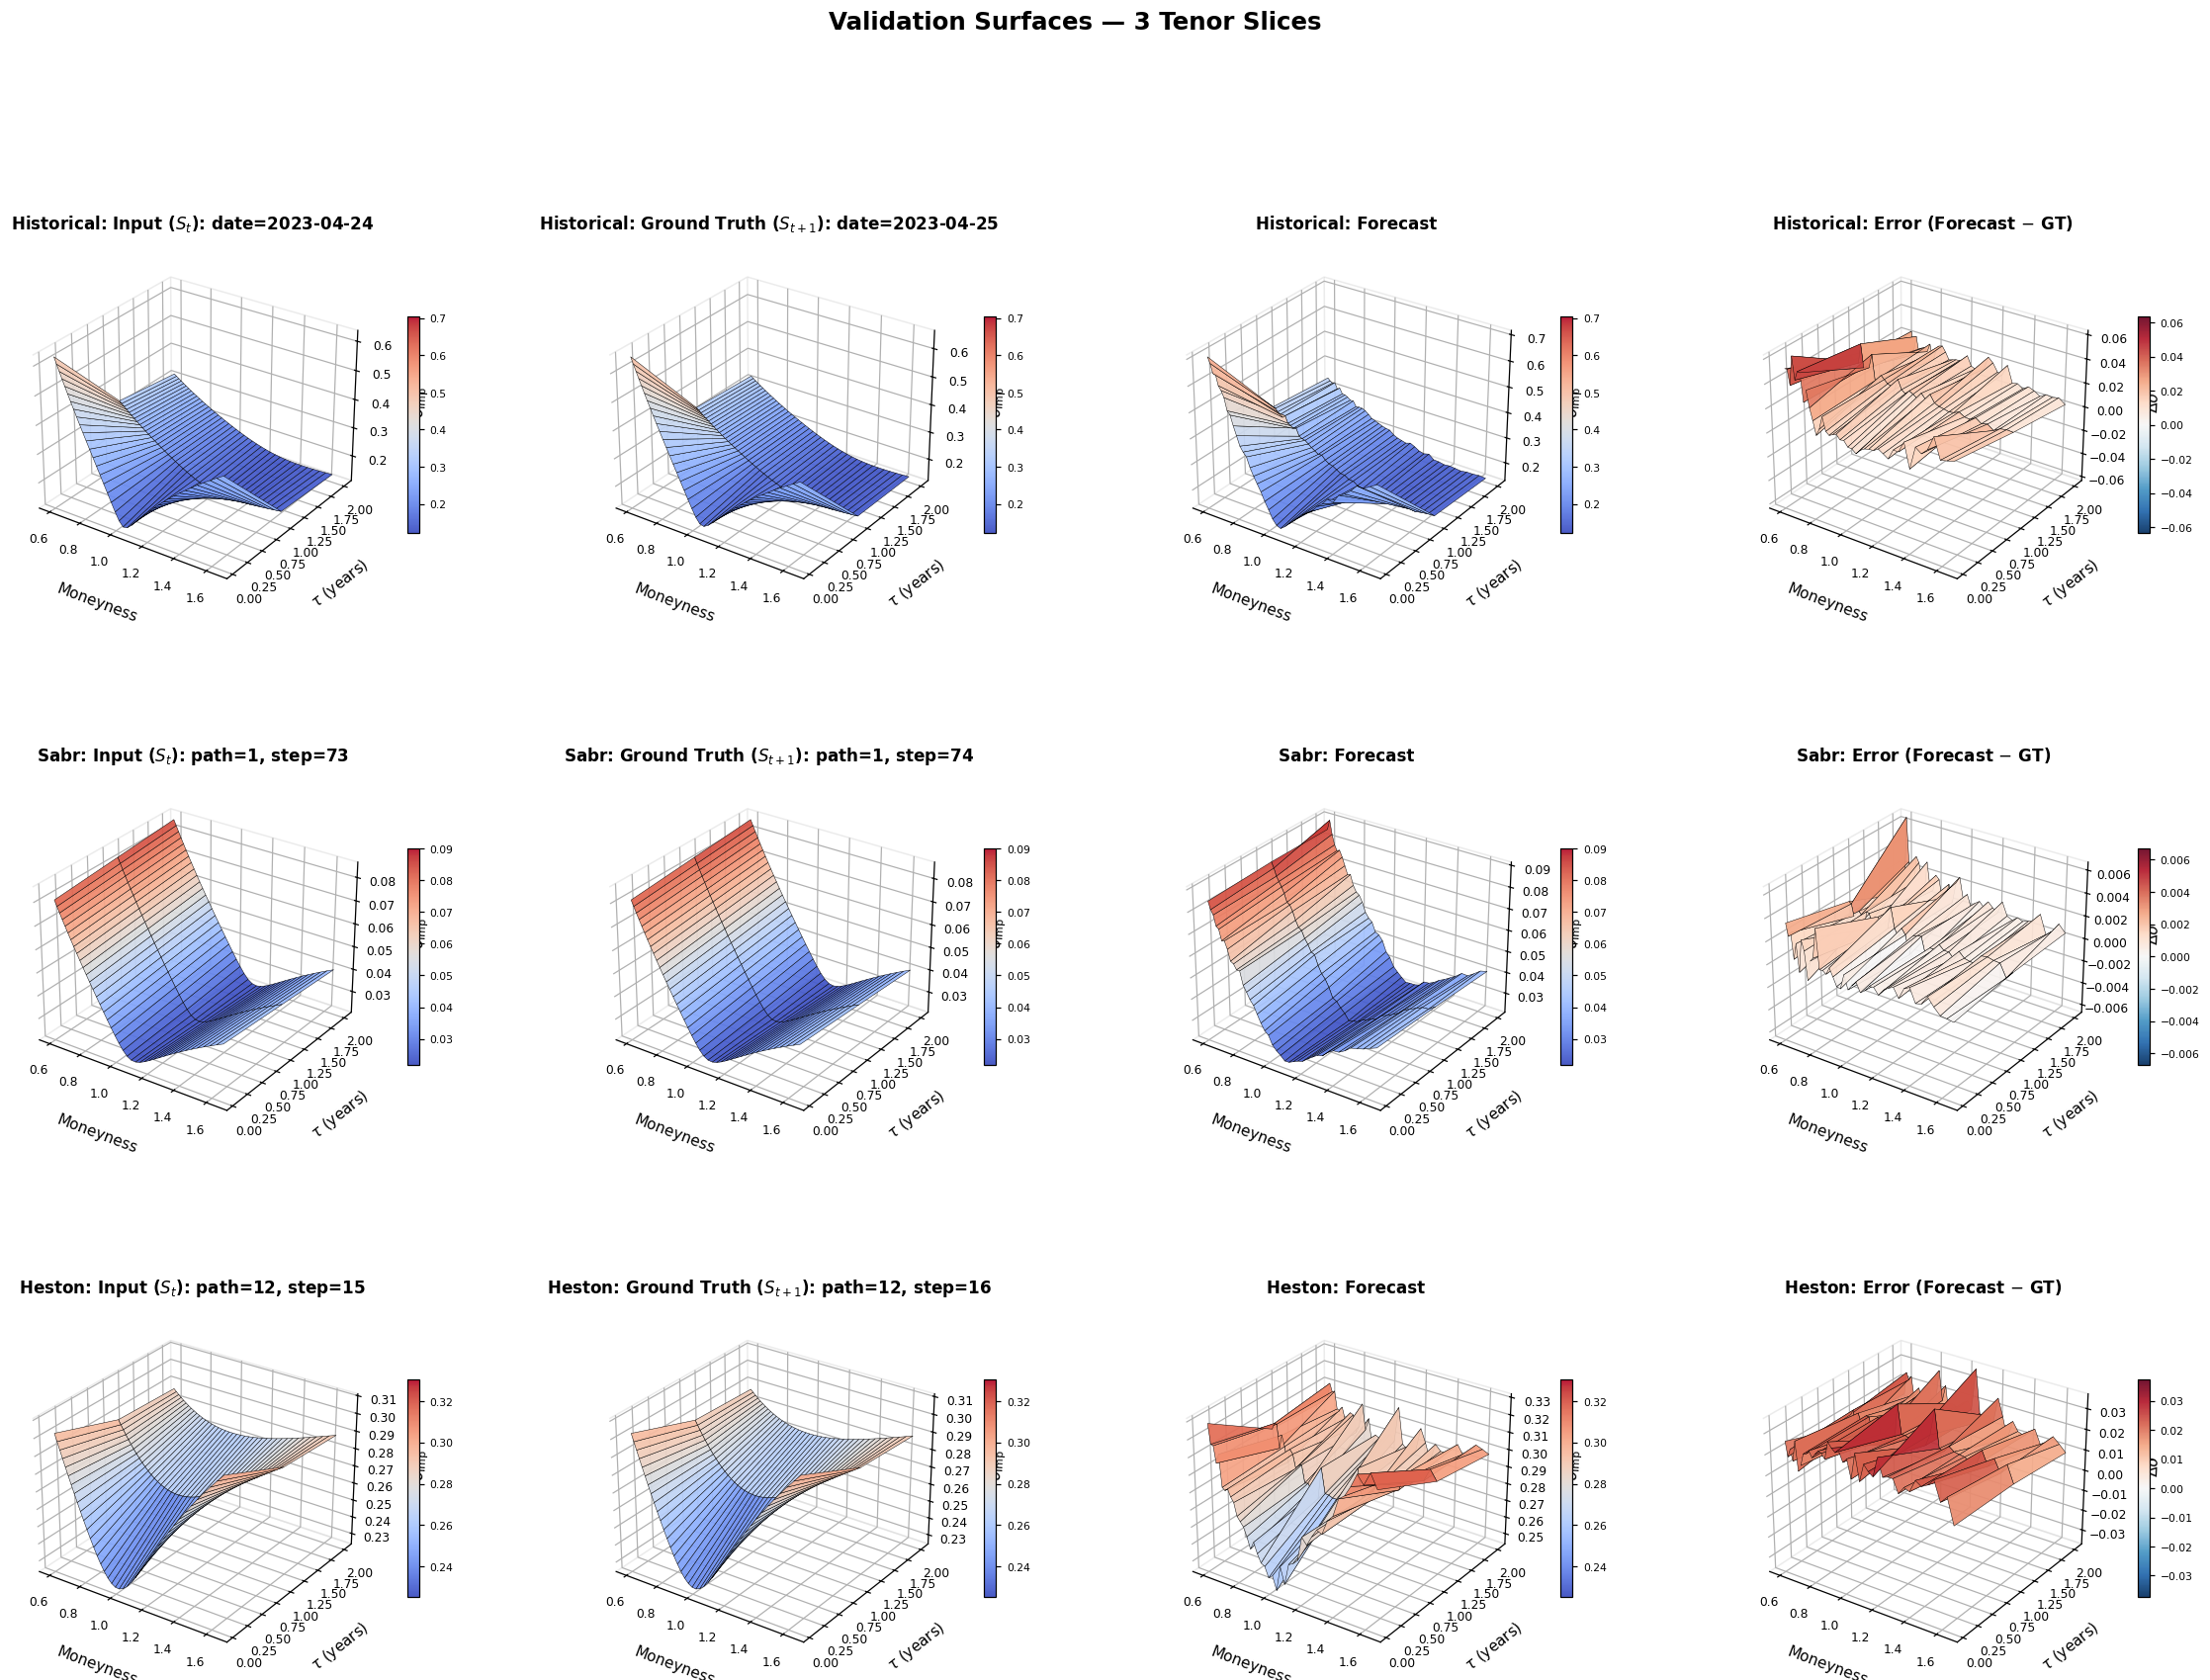

In [9]:
m_axis = np.asarray(moneyness, dtype=np.float64)
tau_axis = np.asarray(GRID.tau, dtype=np.float64)
MM_5, TT_5 = np.meshgrid(m_axis, tau_axis[tenor_idx], indexing="ij")

n_instances = len(instances)

_SURF_CMAP = "coolwarm"
_DIFF_CMAP = "RdBu_r"

_3D_STYLE = {
    "font.family": "sans-serif",
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

with plt.rc_context(_3D_STYLE):
    fig3d = plt.figure(figsize=(26.0, 5.8 * n_instances))
    fig3d.subplots_adjust(wspace=0.25, hspace=0.35)

    for row, inst in enumerate(instances):
        path_label = inst["path_type"].capitalize()
        panels = [
            (inst["input"], f"Input ($S_t$): {inst['input_label']}", _SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
            (
                inst["ground_truth"],
                f"Ground Truth ($S_{{t+1}}$): {inst['gt_label']}",
                _SURF_CMAP,
                r"$\sigma_{\mathrm{imp}}$",
                False,
            ),
            (inst["forecast"], "Forecast", _SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
            (inst["forecast"] - inst["ground_truth"], "Error (Forecast $-$ GT)", _DIFF_CMAP, r"$\Delta\sigma$", True),
        ]

        all_iv_vals = np.concatenate(
            [
                inst["input"][:, tenor_idx].ravel(),
                inst["ground_truth"][:, tenor_idx].ravel(),
                inst["forecast"][:, tenor_idx].ravel(),
            ]
        )
        shared_vmin = float(np.nanmin(all_iv_vals))
        shared_vmax = float(np.nanmax(all_iv_vals))
        if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
            shared_vmin, shared_vmax = 0.0, 1.0

        for col, (iv, title, cmap, zlabel, is_diff) in enumerate(panels):
            ax = fig3d.add_subplot(n_instances, 4, 4 * row + col + 1, projection="3d")
            iv_5 = iv[:, tenor_idx]
            if is_diff:
                panel_abs = float(np.nanmax(np.abs(iv_5)))
                if not np.isfinite(panel_abs) or panel_abs == 0.0:
                    panel_abs = 1.0
                vmin_, vmax_ = -panel_abs, panel_abs
                ax.set_zlim(vmin_, vmax_)
            else:
                vmin_, vmax_ = shared_vmin, shared_vmax

            plotted = ax.plot_surface(
                MM_5,
                TT_5,
                iv_5,
                cmap=cmap,
                vmin=vmin_,
                vmax=vmax_,
                linewidth=0.3,
                edgecolor="k",
                alpha=0.92,
                antialiased=True,
                rstride=1,
                cstride=1,
            )
            ax.set_title(f"{path_label}: {title}", fontsize=11, fontweight="bold", pad=12)
            ax.set_xlabel("Moneyness", labelpad=8)
            ax.set_ylabel(r"$\tau$ (years)", labelpad=10)
            ax.set_zlabel(zlabel, labelpad=6)
            ax.view_init(elev=28, azim=-55)
            ax.tick_params(pad=2)
            ax.xaxis.pane.fill = False
            ax.yaxis.pane.fill = False
            ax.zaxis.pane.fill = False
            ax.xaxis.pane.set_edgecolor("0.85")
            ax.yaxis.pane.set_edgecolor("0.85")
            ax.zaxis.pane.set_edgecolor("0.85")

            cbar = fig3d.colorbar(plotted, ax=ax, shrink=0.55, pad=0.08, aspect=18)
            cbar.ax.tick_params(labelsize=7)

    fig3d.suptitle(
        f"Validation Surfaces — {TENOR_SLICES_PER_SURFACE} Tenor Slices",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )
    fig3d.savefig(
        "validation_input_ground_truth_forecast_difference_3d.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()

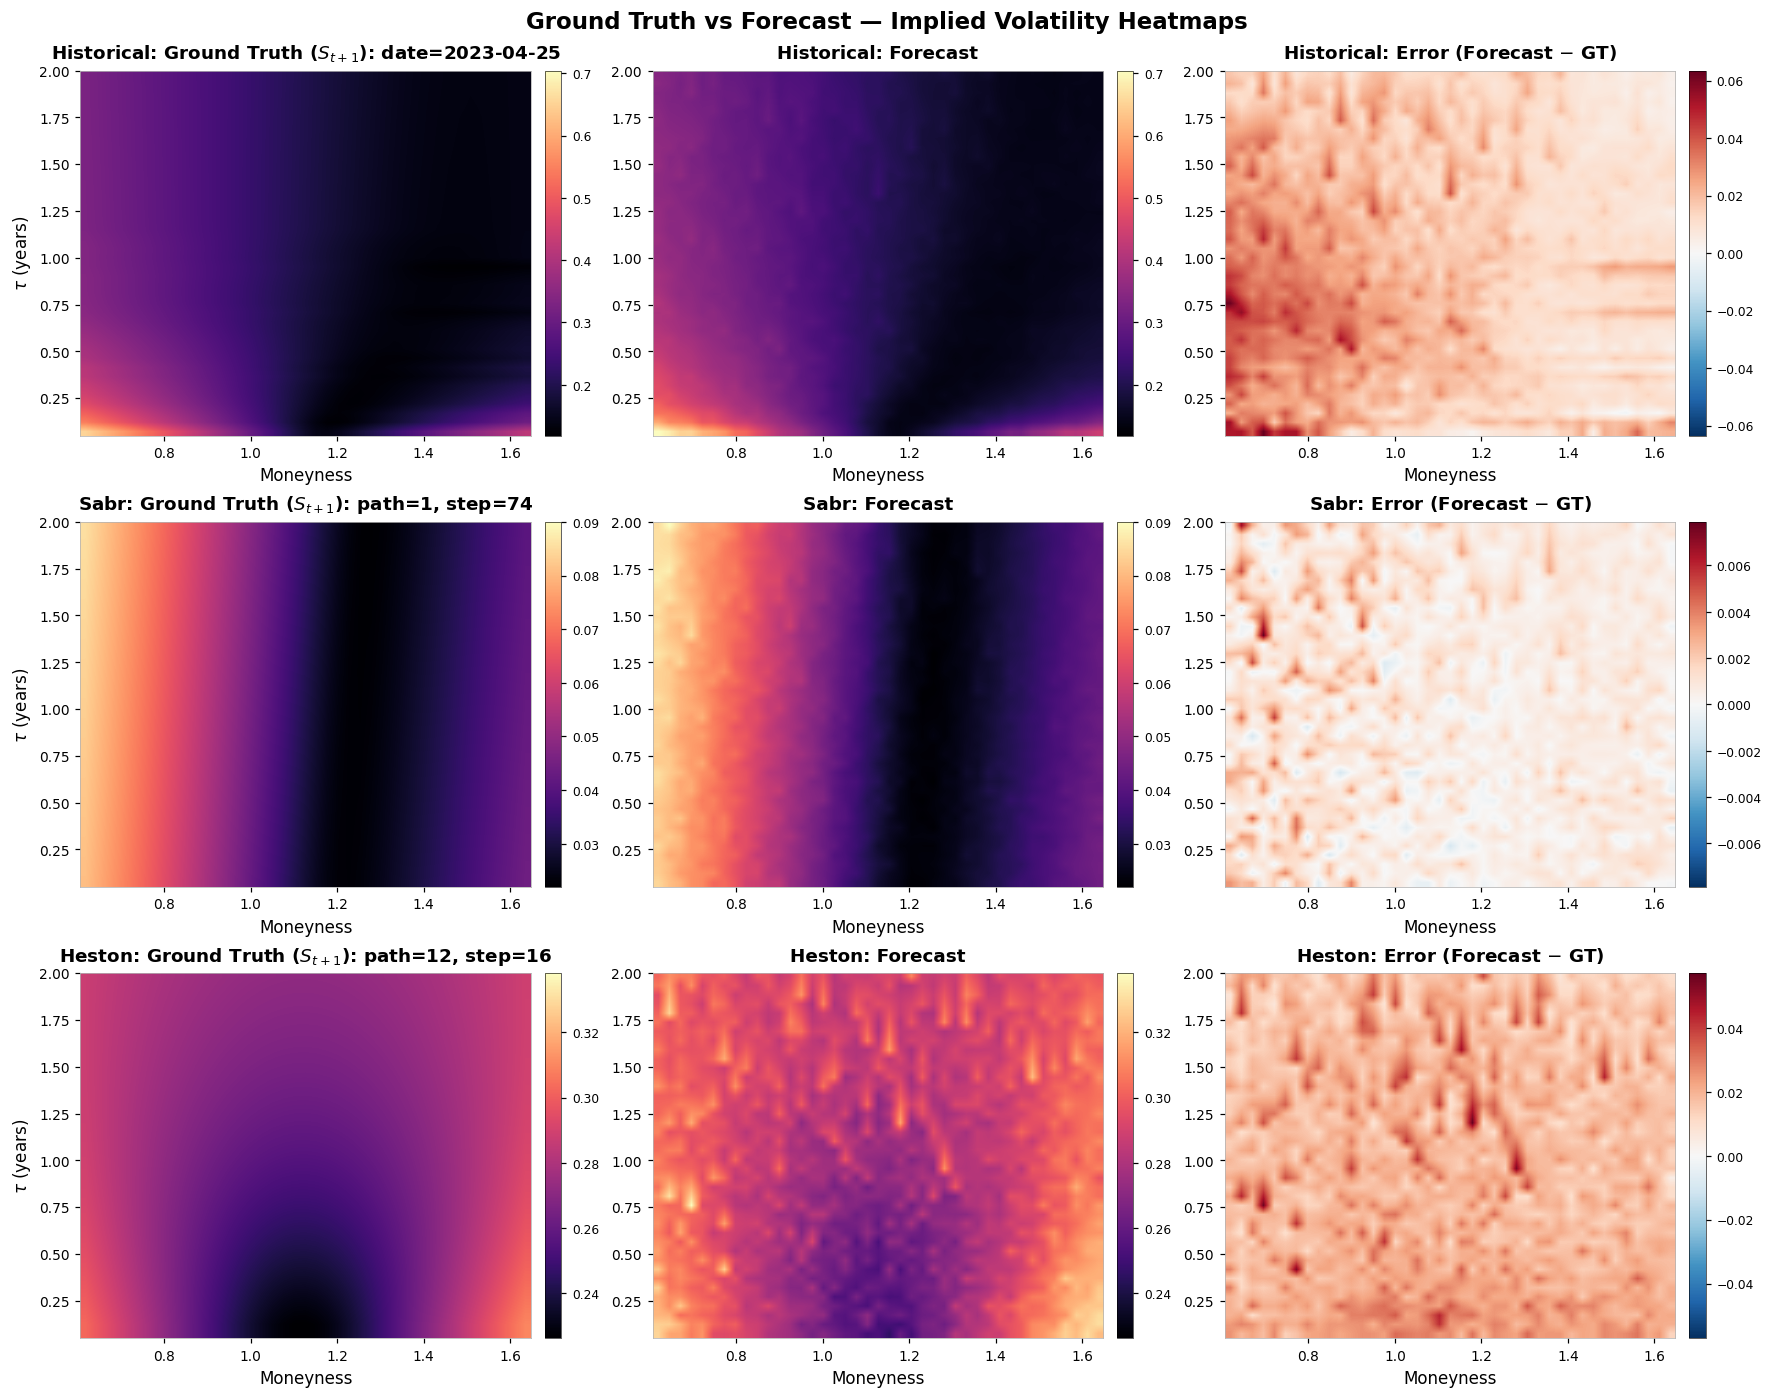

In [10]:
n_instances = len(instances)

_HM_STYLE = {
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
}

with plt.rc_context(_HM_STYLE):
    fig_hm, axes_hm = plt.subplots(
        n_instances,
        3,
        figsize=(16.0, 4.2 * n_instances),
        squeeze=False,
        constrained_layout=True,
    )

    for row, inst in enumerate(instances):
        gt = np.asarray(inst["ground_truth"], dtype=float)
        fc = np.asarray(inst["forecast"], dtype=float)
        err = fc - gt
        path_label = inst["path_type"].capitalize()

        shared_vmin = min(float(np.nanmin(gt)), float(np.nanmin(fc)))
        shared_vmax = max(float(np.nanmax(gt)), float(np.nanmax(fc)))
        if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
            shared_vmin, shared_vmax = 0.0, 1.0

        panels = [
            (gt, f"Ground Truth ($S_{{t+1}}$): {inst['gt_label']}", "magma", r"$\sigma_{\mathrm{imp}}$", False),
            (fc, "Forecast", "magma", r"$\sigma_{\mathrm{imp}}$", False),
            (err, "Error (Forecast $-$ GT)", "RdBu_r", r"$\Delta\sigma$", True),
        ]

        for col, (mat, ttl, cmap, cbar_label, is_diff) in enumerate(panels):
            ax = axes_hm[row, col]
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color("0.7")
                spine.set_linewidth(0.5)

            if is_diff:
                panel_abs = float(np.nanmax(np.abs(mat)))
                if not np.isfinite(panel_abs) or panel_abs == 0.0:
                    panel_abs = 1.0
                vmin_, vmax_ = -panel_abs, panel_abs
            else:
                vmin_, vmax_ = shared_vmin, shared_vmax

            image = ax.imshow(
                mat.T,
                origin="lower",
                aspect="auto",
                extent=(m_axis[0], m_axis[-1], tau_axis[0], tau_axis[-1]),
                cmap=cmap,
                vmin=vmin_,
                vmax=vmax_,
                interpolation="bilinear",
            )
            ax.set_title(f"{path_label}: {ttl}", fontweight="bold", pad=8)
            ax.set_xlabel("Moneyness")
            ax.set_ylabel(r"$\tau$ (years)" if col == 0 else "")
            ax.tick_params(direction="out")

            cbar = fig_hm.colorbar(image, ax=ax, fraction=0.046, pad=0.03, aspect=22)
            cbar.ax.tick_params(labelsize=8)
            cbar.outline.set_linewidth(0.4)

    fig_hm.suptitle(
        "Ground Truth vs Forecast — Implied Volatility Heatmaps",
        fontsize=15,
        fontweight="bold",
    )
    fig_hm.savefig(
        "validation_heatmap_ground_truth_vs_forecast.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()

## Cross-section at selected tenors

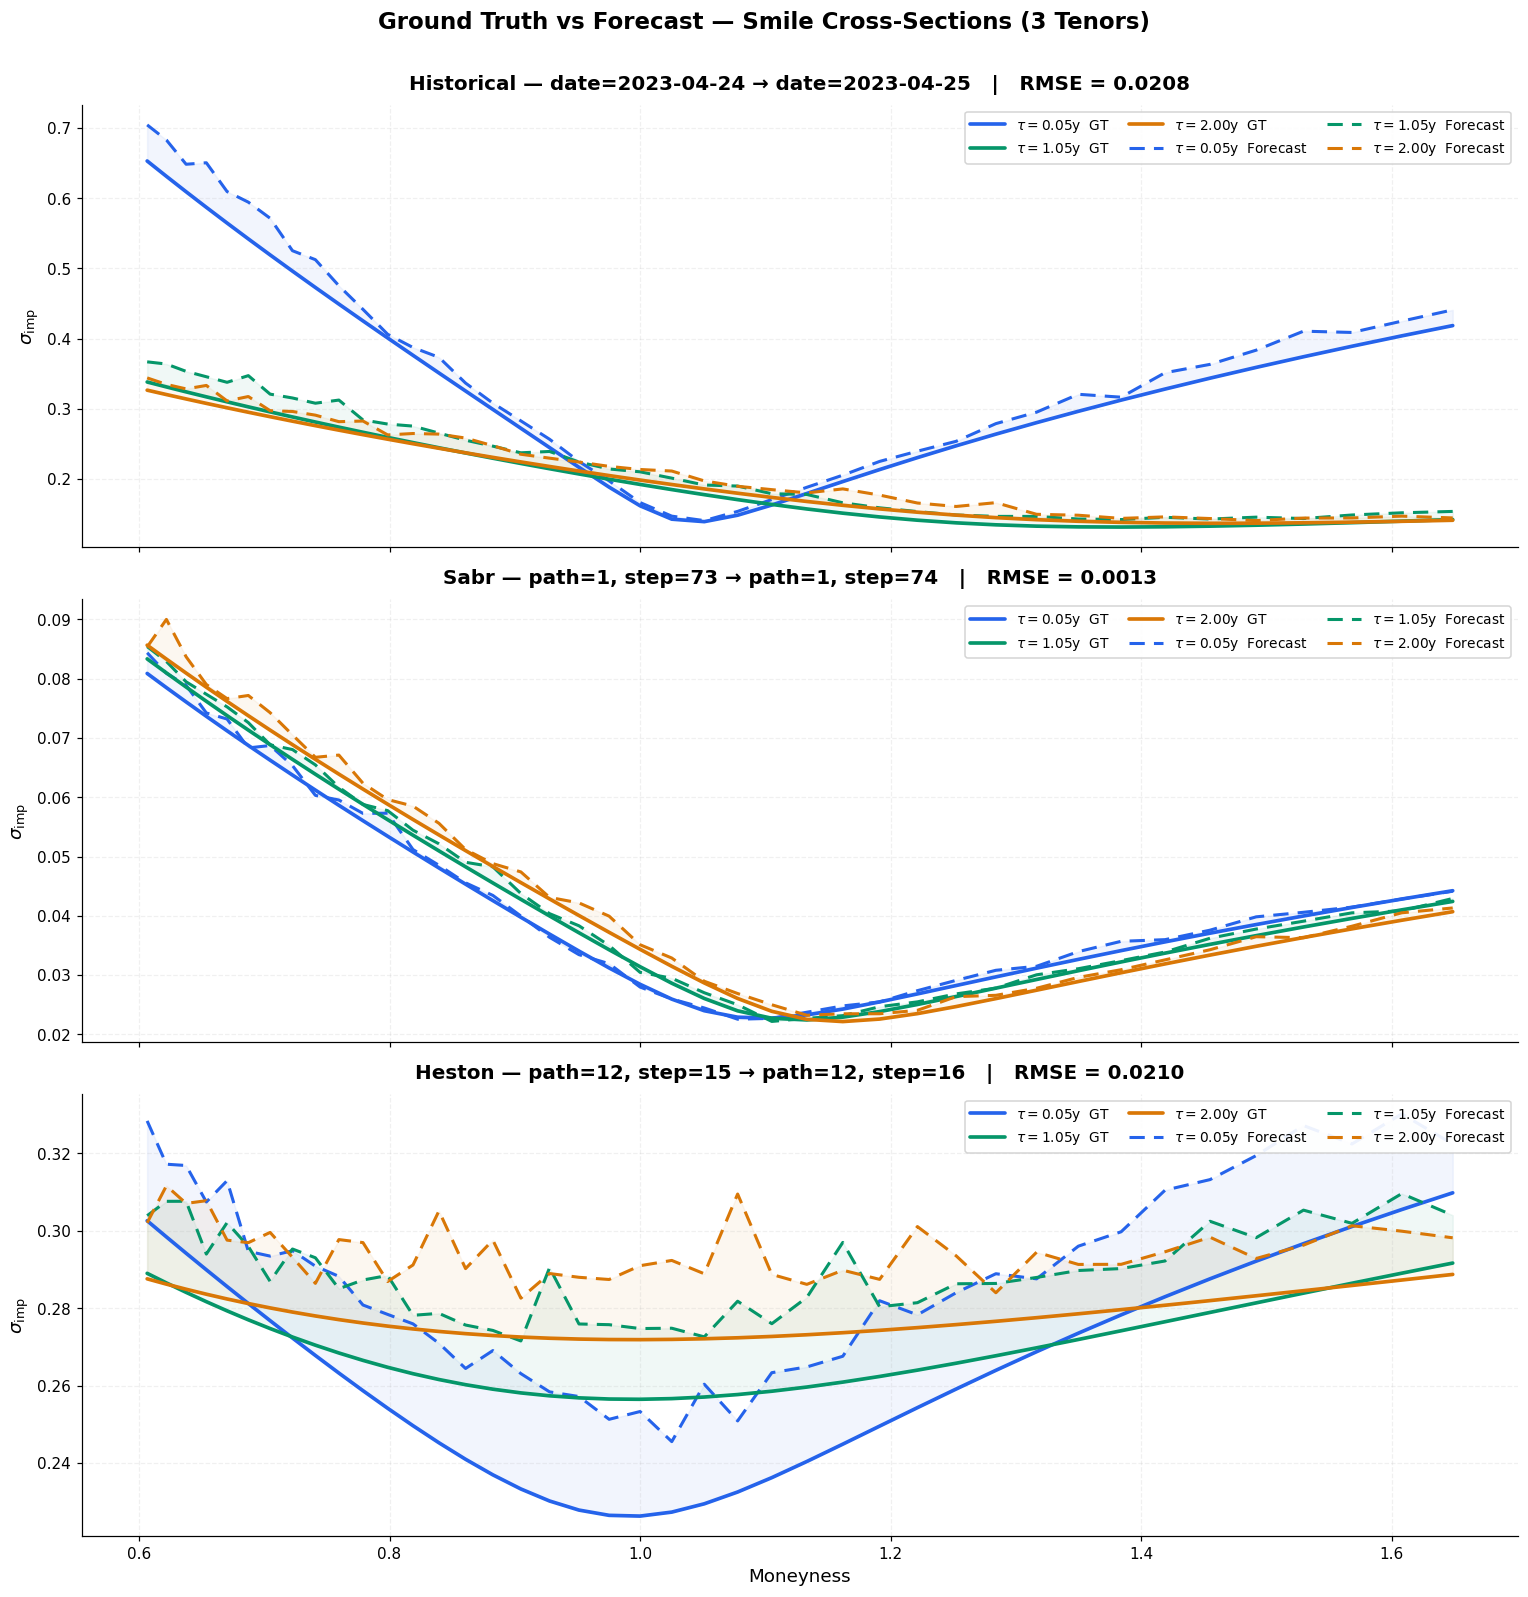

In [ ]:
_TENOR_COLORS = ["#2563eb", "#059669", "#d97706", "#dc2626", "#7c3aed"]

_XS_STYLE = {
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "legend.framealpha": 0.92,
    "legend.edgecolor": "0.82",
}

with plt.rc_context(_XS_STYLE):
    fig, axes = plt.subplots(
        n_instances,
        1,
        figsize=(14, 4.8 * n_instances),
        squeeze=False,
        sharex="col",
    )

    for row, inst in enumerate(instances):
        ax = axes[row, 0]
        gt_iv = inst["ground_truth"]
        fc_iv = inst["forecast"]
        path_label = inst["path_type"].capitalize()

        for j, tidx in enumerate(tenor_idx):
            color = _TENOR_COLORS[j % len(_TENOR_COLORS)]
            tenor_label = rf"$\tau = {tau_axis[tidx]:.2f}$y"
            ax.plot(m_axis, gt_iv[:, tidx], color=color, lw=2.4, solid_capstyle="round", label=f"{tenor_label}  GT")
            ax.plot(
                m_axis, fc_iv[:, tidx], color=color, lw=2.0, ls="--", dashes=(5, 3), label=f"{tenor_label}  Forecast"
            )
            ax.fill_between(m_axis, gt_iv[:, tidx], fc_iv[:, tidx], color=color, alpha=0.06)

        rmse = float(np.sqrt(np.nanmean((fc_iv - gt_iv) ** 2)))
        ax.set_title(
            f"{path_label} — {inst['input_label']} → {inst['gt_label']}   |   RMSE = {rmse:.4f}",
            fontweight="bold",
            pad=10,
        )
        ax.set_ylabel(r"$\sigma_{\mathrm{imp}}$")
        ax.grid(alpha=0.18, ls="--")

        handles, labels = ax.get_legend_handles_labels()
        ncol = min(TENOR_SLICES_PER_SURFACE, 5)
        gt_handles = handles[0::2]
        fc_handles = handles[1::2]
        gt_labels = labels[0::2]
        fc_labels = labels[1::2]
        ax.legend(
            gt_handles + fc_handles,
            gt_labels + fc_labels,
            ncols=ncol,
            loc="upper right",
            handlelength=2.5,
            columnspacing=1.4,
        )

    axes[-1, 0].set_xlabel("Moneyness")
    fig.suptitle(
        f"Ground Truth vs Forecast — Smile Cross-Sections ({TENOR_SLICES_PER_SURFACE} Tenors)",
        fontsize=15,
        fontweight="bold",
        y=1.005,
    )
    fig.tight_layout()
    fig.savefig(
        "validation_cross_section_ground_truth_forecast.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()
    # save as pdf
    fig.savefig(
        "validation_cross_section_ground_truth_forecast.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()